In [1]:
#영화 감성 리뷰
#Netflix의 영화 리뷰 데이터를 사용하여, 리뷰의 평점을 예측해보고, 긍정과 부정 감정을 분류

In [2]:
#필요 라이브러리 임포트
import pandas as pd

#데이터 불러오기
df = pd.read_csv('netflix_reviews.csv')
#데이터 출력
df

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,09ed2c3a-a4ca-4241-a01c-e7543943ee05,reyes Cruz,Very good experience. Great customer service.,5,0,7.89.0 build 18 35322,2024-10-20 14:10:34,7.89.0 build 18 35322
1,b2d324ff-0005-45c4-accf-dc983124400d,NISITH DISSANAYAKE (Widenn Gamer),Bro I was watching w cartoon then this error c...,1,0,8.136.0 build 3 50908,2024-10-20 14:10:25,8.136.0 build 3 50908
2,2d619b1e-aca3-4807-b77f-c9446a606ddf,Evelyn Okoro,Desent,5,0,NaN,2024-10-20 14:06:08,NaN
3,03cc29b9-a49a-4e26-885a-d1652bb669be,Yogesh Bhatta,THIS IS SCAM COMPANY.. THEY JUST LOOT PEOPLE M...,1,0,7.98.0 build 7 35414,2024-10-20 14:02:13,7.98.0 build 7 35414
4,c1b98dcf-0b75-4952-b9ac-6165381f41cf,P3L0NAZ0,Stopped opening. I've uninstalled and reinstal...,1,0,8.136.0 build 3 50908,2024-10-20 14:01:12,8.136.0 build 3 50908
...,...,...,...,...,...,...,...,...
117035,a760ead9-e7aa-4ed1-a651-5c37c3600dac,A Google user,i really like it! there are so many movies and...,5,0,NaN,2019-08-03 15:06:03,NaN
117036,4957f9e7-d7f4-4a52-9764-031cebcac83f,Captain Jeoy,I love Netflix. I always enjoy my time using it.,5,0,8.34.0 build 4 50250,2022-08-15 16:16:30,8.34.0 build 4 50250
117037,9acf7586-7abf-4b50-8c50-3ede3b2a42c4,Suryansh,Sound quality is very slow of movies,1,0,NaN,2020-08-17 07:26:58,NaN
117038,32870f7f-c461-4256-b602-75244ca60248,A Google user,Rate is very expensive.. bcos we see netflix s...,1,0,7.17.0 build 13 34346,2019-07-21 09:41:42,7.17.0 build 13 34346


In [3]:
#데이터 전처리
def preprocess_test(text):
    if isinstance(text, float): #text라는 변수에 담긴 값이 실수(float) 타입인지 검사
        return "" #만약 text가 실수인 경우, 이후의 문자열 처리 과정에서 오류가 발생할 수 있기 때문에, 이와 같은 실수 타입의 데이터는 빈 문자열 ""로 변환
    text = text.lower() #대문자를 소문자로 변환
    text = re.sub(r'[^\w\s]', '', text) #정규 표현식을 사용하여 구두점(마침표, 쉼표 등)을 제거. 단어와 공백(\w와\s)을 제외한 모든 문자를 제거하는 역할
    text = re.sub(r'\d+', '', text) #숫자를 모두 제거, 정규 표현식 \d+는 하나 이상의 숫자를 의미하며, 이를 빈 문자열로 대체
    text = text.strip() #text.strip()은 문자열 양 끝에 있는 불필요한 공백을 제거합니다. 텍스트 중간에 있는 공백은 그대로 두지만, 시작이나 끝부분의 공백은 제거
    return text

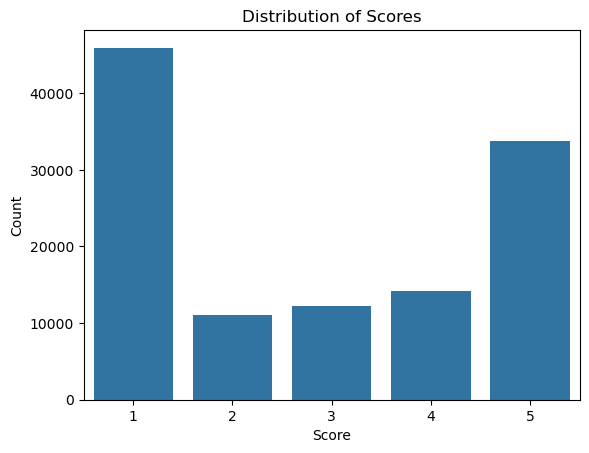

In [4]:
#feature 분석(EDA)

# 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

# 리뷰 점수에 대한 빈도를 계산
score_counts = df['score'].value_counts().sort_index()
#value_counts(): df['score']에 있는 각 점수의 빈도를 계산. 이 함수는 각 점수가 몇 번 나타났는지 계산하여 반환
#sort_index(): 점수의 크기 순으로 정렬 (예. 1점, 2점, 3점 ...)

# 바 그래프 생성
sns.barplot(x=score_counts.index, y=score_counts.values)
# x=score_counts.index: x축에 각 점수(1,2,3,4,5)를 배치
# y=score_counts.value: y축에 각 점수에 해당하는 리뷰의 빈도를 배치

plt.xlabel('Score')  # x축 라벨
plt.ylabel('Count')  # y축 라벨
plt.title('Distribution of Scores')  # 그래프 제목
plt.show() #그래프 출력


In [ ]:
#리뷰 예측 모델 학습시키기(LSTM)